# NextTrack Evaluation Survey Analysis

This notebook analyzes results for the NextTrack software evaluation survey. It focuses on:
- Likert scoring for satisfaction, trust, and perceived privacy
- SUS (System Usability Scale) scoring using the standard 0-100 System Usability Scale formula

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('ggplot')
pd.set_option('display.max_colwidth', 120)

doc_dir = Path.cwd()
csv_candidates = sorted(doc_dir.glob('*.csv'))
if not csv_candidates:
    raise FileNotFoundError('file not found')

csv_path = csv_candidates[0]
df_raw = pd.read_csv(csv_path, encoding='utf-8-sig')

print(f'Loaded: {csv_path.name}')
print(f'Number of responses: {len(df_raw)}')
df_raw.head()

Loaded: NextTrack Music Recommender Evaluation Survey (Responses) - Form responses.csv
Number of responses: 10


,Timestamp,I was satisfied with the playlist creation process.\n我对创建播放列表的过程感到满意。,I understood why songs were being recommended to me.\n我理解为什么系统会向我推荐这些歌曲。,I felt that my data and privacy were respected while using the app.\n我觉得应用在使用过程中尊重了我的数据和隐私。,I trust the recommendations made by the app.\n我信任该应用给出的推荐结果。,"Adjusting the controls (genre, diverse artists toggle) changed the recommendations in a way I could understand.\n调整控制项（音乐类型、歌手多样性开关）后，推荐结果的变化是我能够理解的。",I think that I would like to use this system frequently.\n我认为我会愿意经常使用这个系统。,I found the system unnecessarily complex.\n我觉得这个系统没有必要地过于复杂。,I thought the system was easy to use.\n我认为这个系统易于使用。,I think that I would need the support of a technical person to be able to use this system.\n我认为如果没有技术人员的帮助，我将无法使用这个系统。,I found the various functions in this system were well integrated.\n我觉得这个系统中的各项功能整合得很好。,I thought there was too much inconsistency in this system.\n我觉得这个系统存在太多不一致的地方。\n,I would imagine that most people would learn to use this system very quickly.\n我认为大多数人都能很快学会如何使用这个系统。,I found the system very cumbersome to use.\n我觉得这个系统使用起来非常繁琐。,I felt very confident using the system.\n我在使用这个系统时感到很有信心。,I needed to learn a lot of things before I could get going with this system.\n我觉得在开始使用这个系统之前，需要先学习很多东西。,"Do you have any additional comments, suggestions, or issues you would like to share about your experience using NextTrack? （optional）\n您对使用 NextTrack 的体验还有其他反馈吗？（选答）"
0,21/03/2026 09:46:35,5,4,5,5,5,4,1,5,1,4,1,4,1,4,1,NaN
1,21/03/2026 10:44:03,3,2,5,2,5,3,1,5,1,2,4,5,1,4,1,NaN
2,21/03/2026 10:50:24,4,5,4,4,5,3,1,5,1,4,2,5,2,5,1,"It's nice to be able to skip between songs using the arrow keys, but it would also be handy to be able to jump direc..."
3,21/03/2026 11:49:22,5,4,5,5,4,4,1,5,1,4,1,4,1,4,1,NaN
4,21/03/2026 12:14:31,5,4,4,4,5,5,1,5,1,5,1,5,1,4,1,"Beautiful and straight forward layout. The “day and night” mode is great! The app is easy to use, especially the opt..."


In [8]:
def find_col(prefix: str) -> str:
    for col in df_raw.columns:
        if col.startswith(prefix):
            return col
    raise KeyError(f'Could not find a column starting with: {prefix}')

likert_cols = {
    'Satisfaction': find_col('I was satisfied with the playlist creation process.'),
    'Trust': find_col('I trust the recommendations made by the app.'),
    'Perceived privacy': find_col('I felt that my data and privacy were respected while using the app.'),
}

sus_prefixes = [
    'I think that I would like to use this system frequently.',
    'I found the system unnecessarily complex.',
    'I thought the system was easy to use.',
    'I think that I would need the support of a technical person to be able to use this system.',
    'I found the various functions in this system were well integrated.',
    'I thought there was too much inconsistency in this system.',
    'I would imagine that most people would learn to use this system very quickly.',
    'I found the system very cumbersome to use.',
    'I felt very confident using the system.',
    'I needed to learn a lot of things before I could get going with this system.',
]
sus_cols = [find_col(prefix) for prefix in sus_prefixes]

df = df_raw.copy()
for col in list(likert_cols.values()) + sus_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

likert_df = df[list(likert_cols.values())].rename(columns={v: k for k, v in likert_cols.items()})
likert_df.head()

,Satisfaction,Trust,Perceived privacy
0,5,5,5
1,3,2,5
2,4,4,4
3,5,5,5
4,5,4,4


In [9]:
def likert_summary(series: pd.Series) -> pd.Series:
    valid = series.dropna()
    return pd.Series({
        'n': int(valid.count()),
        'mean': valid.mean(),
        'median': valid.median(),
        'std': valid.std(ddof=1),
        'iqr': valid.quantile(0.75) - valid.quantile(0.25),
        'min': valid.min(),
        'max': valid.max(),
        'positive_share_%': valid.ge(4).mean() * 100,
    })

likert_summary_table = likert_df.apply(likert_summary).T.round(2)
likert_distribution = pd.DataFrame({
    metric: likert_df[metric].value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
    for metric in likert_df.columns
}).T

print('Likert summary statistics')
display(likert_summary_table)

print('Likert response counts by rating')
display(likert_distribution)

Likert summary statistics


,n,mean,median,std,iqr,min,max,positive_share_%
Satisfaction,10.0,4.0,4.0,0.94,2.0,3.0,5.0,60.0
Trust,10.0,3.5,4.0,1.43,2.5,1.0,5.0,60.0
Perceived privacy,10.0,4.5,5.0,0.71,1.0,3.0,5.0,90.0


Likert response counts by rating


,1,2,3,4,5
Satisfaction,0,0,4,2,4
Trust,1,2,1,3,3
Perceived privacy,0,0,1,3,6


In [ ]:
sus_df = df[sus_cols].copy()

odd_items = sus_df.iloc[:, [0, 2, 4, 6, 8]] - 1
even_items = 5 - sus_df.iloc[:, [1, 3, 5, 7, 9]]
sus_scores = pd.concat([odd_items, even_items], axis=1).sum(axis=1) * 2.5

sus_summary = pd.Series({
    'mean_SUS': sus_scores.mean(),
    'median_SUS': sus_scores.median(),
    'min_SUS': sus_scores.min(),
    'max_SUS': sus_scores.max(),
    'share_above_68_%': sus_scores.ge(68).mean() * 100,
}).round(2)

sus_results = pd.DataFrame({
    'Participant': np.arange(1, len(sus_scores) + 1),
    'SUS score': sus_scores.round(2),
})

print('SUS summary statistics')
display(sus_summary.to_frame(name='value'))

print('Participant-level SUS scores')
display(sus_results)

SUS summary statistics


,value
n,10.00
mean_SUS,89.50
median_SUS,90.00
std_SUS,7.05
min_SUS,77.50
max_SUS,97.50
share_above_68_%,100.00


Participant-level SUS scores


,Participant,SUS score
0,1,90.0
1,2,77.5
2,3,87.5
3,4,90.0
4,5,97.5
5,6,95.0
6,7,95.0
7,8,80.0
8,9,97.5
9,10,85.0


In [11]:
benchmark_summary = pd.DataFrame({
    'Criterion': [
        'Median satisfaction in positive range (>= 4)',
        'Median trust in positive range (>= 4)',
        'Median perceived privacy in positive range (>= 4)',
        'Mean SUS above acceptable benchmark (>= 68)',
    ],
    'Met?': [
        likert_df['Satisfaction'].median() >= 4,
        likert_df['Trust'].median() >= 4,
        likert_df['Perceived privacy'].median() >= 4,
        sus_scores.mean() >= 68,
    ]
})

benchmark_summary

,Criterion,Met?
0,Median satisfaction in positive range (>= 4),True
1,Median trust in positive range (>= 4),True
2,Median perceived privacy in positive range (>= 4),True
3,Mean SUS above acceptable benchmark (>= 68),True


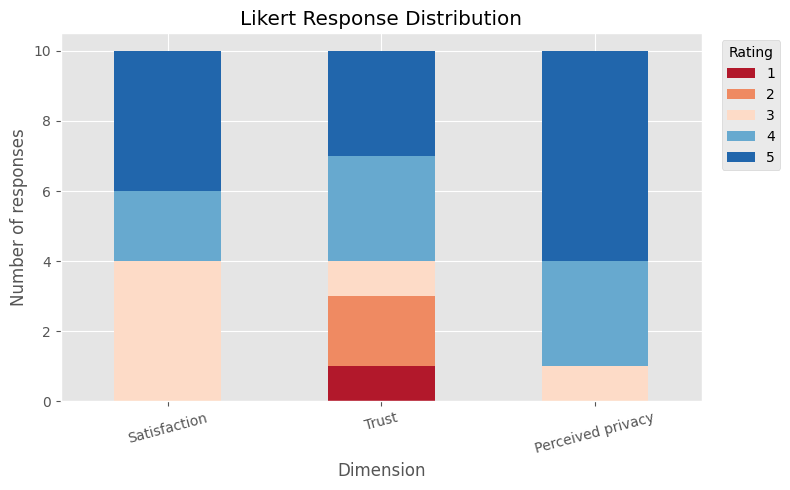

Saved figure: /Users/Manon/Documents/prj/fp/fp/next_track/documentation/likert_feedback_summary.png


In [ ]:
likert_fig_path = doc_dir / 'likert_feedback_summary.png'

fig, ax = plt.subplots(figsize=(8, 5))
likert_distribution[[1, 2, 3, 4, 5]].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#b2182b', '#ef8a62', '#fddbc7', '#67a9cf', '#2166ac']
)
ax.set_title('Likert Response Distribution')
ax.set_xlabel('Dimension')
ax.set_ylabel('Number of responses')
ax.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(likert_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Likert response distribution path: {likert_fig_path}')

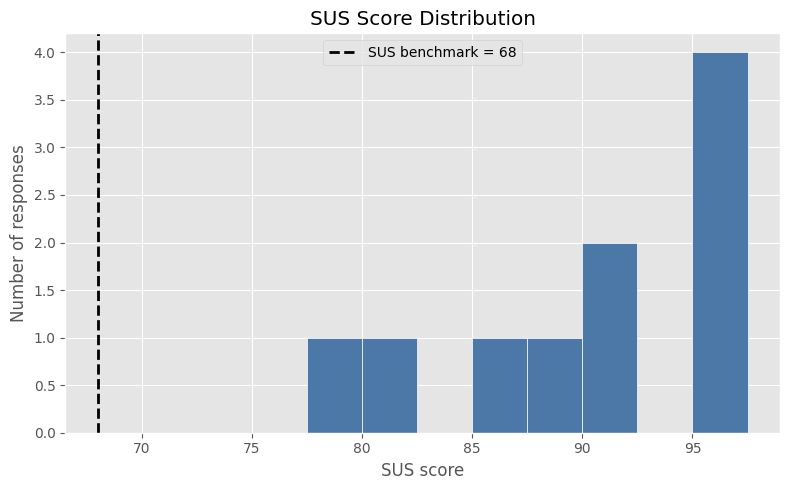

Saved figure: /Users/Manon/Documents/prj/fp/fp/next_track/documentation/sus_score_distribution.png


In [ ]:
sus_fig_path = doc_dir / 'sus_score_distribution.png'

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sus_scores.dropna(), bins=min(8, len(sus_scores)), color='#4c78a8', edgecolor='white')
ax.axvline(68, color='black', linestyle='--', linewidth=2, label='SUS benchmark = 68')
ax.set_title('SUS Score Distribution')
ax.set_xlabel('SUS score')
ax.set_ylabel('Number of responses')
ax.legend()
fig.tight_layout()
fig.savefig(sus_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'SUS score distribution path: {sus_fig_path}')